In [1]:
import kagglehub
path = kagglehub.dataset_download("mithramadapa25/ngram-20k")
print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/mithramadapa25/ngram-20k


In [2]:
import time
training_start_time = time.time()
print("⏱ Runtime tracker started.")

⏱ Runtime tracker started.


# 📦 Imports & Setup

In [3]:
import pandas as pd
import numpy as np
import re
import time
import os
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.multiclass import OneVsRestClassifier
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.metrics import (
    classification_report,
    accuracy_score,
    f1_score,
    hamming_loss
)
from sklearn.tree import DecisionTreeClassifier

OUTPUT_DIR = "/kaggle/working/outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

total_start = time.time()

print("✅ Setup completed.")

✅ Setup completed.


# 📂 Load Data

In [4]:
file_path = "/kaggle/input/datasets/mithramadapa25/ngram-20k/n_gram_20k.xlsx"
df = pd.read_excel(file_path)

TEXT_COL  = 'Text'
LABEL_COL = 'Detected Alankars'

# Remove NaN label rows
df = df[df[LABEL_COL].notna()]

print("Dataset shape after removing NaN labels:", df.shape)
print(df.head())

print("✅ Data loaded and NaN labels removed.")

Dataset shape after removing NaN labels: (20014, 5)
   Poem ID                    Title    Line Group  \
0        1  नया रास्ता (Naya Rasta)  Lines 1 to 1   
1        1  नया रास्ता (Naya Rasta)  Lines 2 to 2   
3        1  नया रास्ता (Naya Rasta)  Lines 4 to 4   
5        1  नया रास्ता (Naya Rasta)  Lines 6 to 6   
6        1  नया रास्ता (Naya Rasta)  Lines 7 to 7   

                                                Text  \
0            जब सारे जाने हुए रास्ते बंद हो जाते हैं   
1          तो आदमी एक नए रास्ते के बारे में सोचता है   
3                  एक नए प्रयास के बारे में सोचता है   
5                             एक नई ताक़त से लगता है   
6  एक नई ताक़त वाला आदमी बिल्कुल एक नया आदमी होता है   

              Detected Alankars  
0  Yamak, Anupras, Upma, Roopak  
1                        Roopak  
3                        Roopak  
5       Upma, Utpreksha, Roopak  
6        Yamak, Anupras, Roopak  
✅ Data loaded and NaN labels removed.


# 🧹 Clean Text

In [5]:
def clean_text(text):
    text = str(text)
    text = re.sub(r'[^\u0900-\u097F\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df[TEXT_COL] = df[TEXT_COL].apply(clean_text)
df = df[df[TEXT_COL].str.strip() != ""].reset_index(drop=True)

print("✅ Text cleaned.")

✅ Text cleaned.


# 🏷️ Label Encoding

In [6]:
def parse_labels(label_str):
    if pd.isna(label_str):
        return []
    return [x.strip() for x in str(label_str).split(',') if x.strip() and x.strip().lower() != 'nan']

df['labels_list'] = df[LABEL_COL].apply(parse_labels)

# Remove rows with empty labels after cleaning
df = df[df['labels_list'].map(len) > 0]

mlb = MultiLabelBinarizer()
Y = mlb.fit_transform(df['labels_list'])

class_names = list(mlb.classes_)
num_classes = len(class_names)

print("Classes:", class_names)
print("✅ Labels processed.")

Classes: ['Anupras', 'Roopak', 'Shlesh', 'Upma', 'Utpreksha', 'Virodhbhas', 'Yamak']
✅ Labels processed.


# ✂️ Train / Validation Split

In [7]:
X_train_raw, X_val_raw, y_train, y_val = train_test_split(
    df[TEXT_COL],
    Y,
    test_size=0.1,
    random_state=42
)

print(len(X_train_raw), len(X_val_raw))
print("✅ Data split completed.")

18012 2002
✅ Data split completed.


# 🔢 TF-IDF Vectorization

In [8]:
vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),
    max_features=50000,
    sublinear_tf=True
)

X_train_vec = vectorizer.fit_transform(X_train_raw)
X_val_vec   = vectorizer.transform(X_val_raw)

print(X_train_vec.shape)
print("✅ TF-IDF completed.")

(18012, 2660)
✅ TF-IDF completed.


# 🛠️ Evaluation Helper

In [9]:
def evaluate_model(model_name, model, X_train, y_train, X_val, y_val, class_names, output_dir):
    """Evaluate a trained multi-label model and save a heatmap."""
    y_train_pred = model.predict(X_train)
    y_pred       = model.predict(X_val)

    subset_acc_train = accuracy_score(y_train, y_train_pred)
    subset_acc_val   = accuracy_score(y_val, y_pred)

    train_f1_micro = f1_score(y_train, y_train_pred, average='micro', zero_division=0)
    val_f1_micro   = f1_score(y_val, y_pred, average='micro', zero_division=0)

    train_f1_macro = f1_score(y_train, y_train_pred, average='macro', zero_division=0)
    val_f1_macro   = f1_score(y_val, y_pred, average='macro', zero_division=0)

    train_hamming_loss = hamming_loss(y_train, y_train_pred)
    val_hamming_loss   = hamming_loss(y_val, y_pred)

    train_hamming_acc = 1 - train_hamming_loss
    val_hamming_acc   = 1 - val_hamming_loss

    print(f"\n{'='*60}")
    print(f"  {model_name}")
    print(f"{'='*60}")
    print(f"{'Metric':<25} {'Train':>12} {'Validation':>12}")
    print(f"{'='*60}")
    print(f"{'Subset Accuracy':<25} {subset_acc_train:>12.4f} {subset_acc_val:>12.4f}")
    print(f"{'F1 Micro':<25} {train_f1_micro:>12.4f} {val_f1_micro:>12.4f}")
    print(f"{'F1 Macro':<25} {train_f1_macro:>12.4f} {val_f1_macro:>12.4f}")
    print(f"{'Hamming Loss':<25} {train_hamming_loss:>12.4f} {val_hamming_loss:>12.4f}")
    print(f"{'Hamming Accuracy':<25} {train_hamming_acc:>12.4f} {val_hamming_acc:>12.4f}")
    print(f"{'='*60}")
    print("\nClassification Report:\n")
    print(classification_report(y_val, y_pred, target_names=class_names, zero_division=0))

    # Heatmap
    n = len(class_names)
    y_true_arr = np.array(y_val)
    y_pred_arr = np.array(y_pred)
    cm = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            cm[i, j] = np.sum((y_true_arr[:, i] == 1) & (y_pred_arr[:, j] == 1))

    plt.figure(figsize=(12, 9))
    sns.heatmap(cm, annot=True, fmt=".0f", cmap="magma",
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f"Multi-label Prediction Heatmap — {model_name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    safe = model_name.lower().replace(' ', '_').replace('(','').replace(')','').replace('+','').replace('/','')
    plt.savefig(os.path.join(output_dir, f"heatmap_{safe}.png"), dpi=150)
    plt.show()
    print(f"✅ {model_name} evaluation completed.")
    return y_pred

print("✅ Evaluation function defined.")

✅ Evaluation function defined.


---
## Algorithm 5 — Decision Tree (OvR)

In [10]:
from sklearn.tree import DecisionTreeClassifier

train_start = time.time()

model = OneVsRestClassifier(
    DecisionTreeClassifier(
        class_weight='balanced',
        max_depth=20,
        min_samples_split=10,
        random_state=42
    ),
    n_jobs=-1
)
model.fit(X_train_vec, y_train)

print(f"Training time: {time.time() - train_start:.2f}s")
print("✅ Decision Tree training completed.")

Training time: 11.20s
✅ Decision Tree training completed.



  Decision Tree (OvR)
Metric                           Train   Validation
Subset Accuracy                 0.8141       0.7797
F1 Micro                        0.9693       0.9627
F1 Macro                        0.9738       0.9650
Hamming Loss                    0.0403       0.0494
Hamming Accuracy                0.9597       0.9506

Classification Report:

              precision    recall  f1-score   support

     Anupras       1.00      0.94      0.97      1951
      Roopak       1.00      0.91      0.95      1812
      Shlesh       0.97      0.98      0.97       731
        Upma       1.00      0.93      0.96      1825
   Utpreksha       0.96      0.98      0.97       697
  Virodhbhas       0.96      0.99      0.97       588
       Yamak       0.99      0.93      0.96      1909

   micro avg       0.99      0.94      0.96      9513
   macro avg       0.98      0.95      0.96      9513
weighted avg       0.99      0.94      0.96      9513
 samples avg       0.95      0.90      0.92 

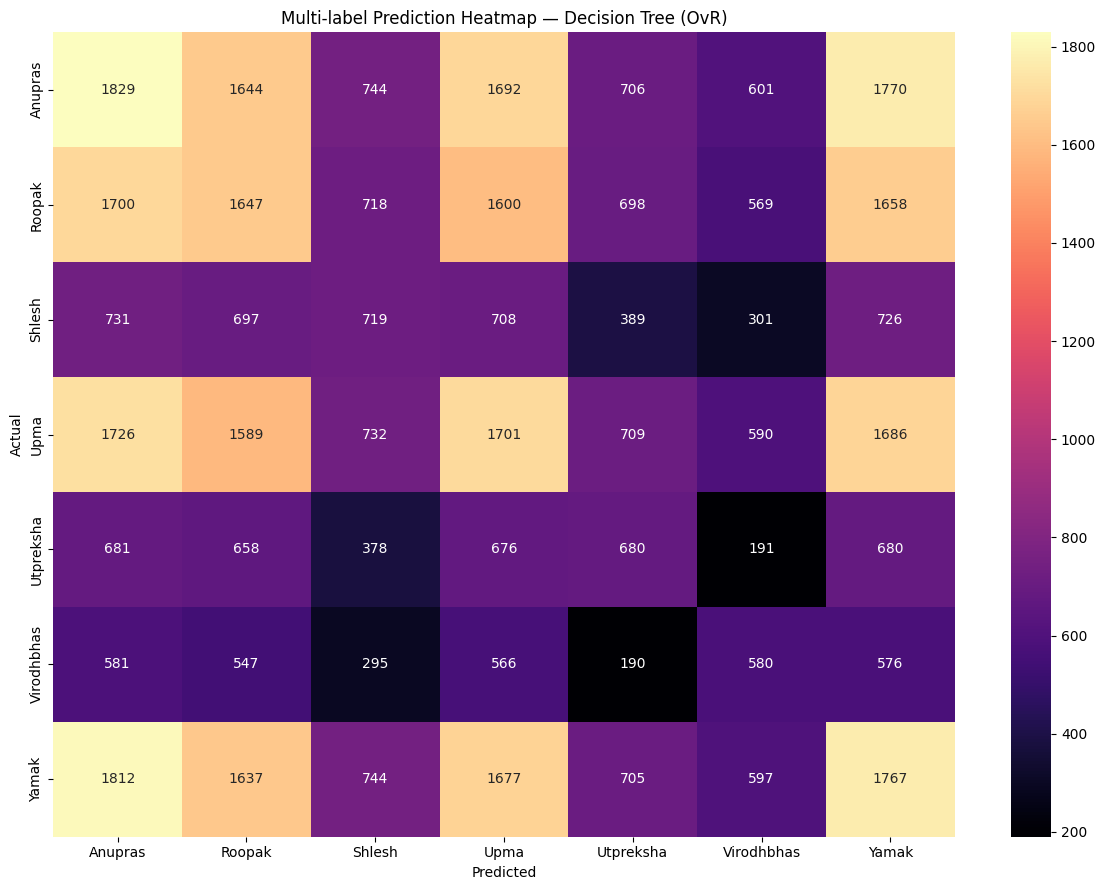

✅ Decision Tree (OvR) evaluation completed.


array([[1, 0, 1, ..., 0, 0, 1],
       [1, 0, 0, ..., 0, 1, 1],
       [1, 1, 1, ..., 0, 0, 1],
       ...,
       [1, 1, 0, ..., 0, 1, 1],
       [1, 1, 0, ..., 0, 1, 1],
       [1, 1, 0, ..., 0, 0, 1]])

In [11]:
evaluate_model("Decision Tree (OvR)", model,
               X_train_vec, y_train, X_val_vec, y_val,
               class_names, OUTPUT_DIR)

## 💾 Save Model

In [12]:
joblib.dump(model,      os.path.join(OUTPUT_DIR, "model_dt.joblib"))
joblib.dump(vectorizer, os.path.join(OUTPUT_DIR, "vectorizer.joblib"))
joblib.dump(mlb,        os.path.join(OUTPUT_DIR, "mlb.joblib"))
print("✅ Model saved.")

✅ Model saved.


In [13]:
total_seconds = time.time() - training_start_time
hours   = int(total_seconds // 3600)
minutes = int((total_seconds % 3600) // 60)
seconds = int(total_seconds % 60)

print(" " + "="*50)
print(f"⏱  TOTAL RUNTIME: {hours}h {minutes}m {seconds}s")
print("="*50)

⏱  TOTAL RUNTIME: 0h 0m 20s


## 🔍 Unseen Text Prediction (VIVA / Demo)

In [14]:
# ─── Unseen Text Prediction (VIVA / Demo) ───────────────────────────────────
unseen_texts = [
    "काली घटा का घमंड घटा, नभ मंडल तारों से सज गया",
    "रहिमन पानी राखिए बिन पानी सब सून, पानी गए न ऊबरे मोती मानुस चून",
    "मानो नदी का जल चांदी की चादर बिछा रहा हो संसार में",
    "जब सारे जाने हुए रास्ते बंद हो जाते हैं, तब नया रास्ता खुद बनाना पड़ता है",
    "उसका मुख चंद्रमा सा शीतल और नयन कमल से विशाल हैं",
    "प्रियतम प्रेम प्रकाश प्रसारित, पल पल पावन पथ पर चलते",
    "नयन नीर बह चले, मन मोर नाचे, प्रेम पंथ पर पग धरे",
]

cleaned_texts = [clean_text(t) for t in unseen_texts]
X_unseen = vectorizer.transform(cleaned_texts)

y_unseen_pred = model.predict(X_unseen)
predicted_labels = mlb.inverse_transform(y_unseen_pred)

print("🔍 UNSEEN TEXT PREDICTIONS:\n")
for text, labels in zip(unseen_texts, predicted_labels):
    print(f"Text: {text}")
    print(f"Predicted Alankars: {labels if labels else 'None'}")
    print("-" * 60)

print("✅ Unseen text prediction completed.")

🔍 UNSEEN TEXT PREDICTIONS:

Text: काली घटा का घमंड घटा, नभ मंडल तारों से सज गया
Predicted Alankars: ('Anupras',)
------------------------------------------------------------
Text: रहिमन पानी राखिए बिन पानी सब सून, पानी गए न ऊबरे मोती मानुस चून
Predicted Alankars: ('Upma',)
------------------------------------------------------------
Text: मानो नदी का जल चांदी की चादर बिछा रहा हो संसार में
Predicted Alankars: None
------------------------------------------------------------
Text: जब सारे जाने हुए रास्ते बंद हो जाते हैं, तब नया रास्ता खुद बनाना पड़ता है
Predicted Alankars: None
------------------------------------------------------------
Text: उसका मुख चंद्रमा सा शीतल और नयन कमल से विशाल हैं
Predicted Alankars: None
------------------------------------------------------------
Text: प्रियतम प्रेम प्रकाश प्रसारित, पल पल पावन पथ पर चलते
Predicted Alankars: ('Anupras',)
------------------------------------------------------------
Text: नयन नीर बह चले, मन मोर नाचे, प्रेम पंथ पर पग धरे
Predict